In [71]:
# Import des bibliothèques nécessaires pour le traitement des données,
# l'entraînement du modèle Logistic Regression et l'évaluation des performances.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve

)
from tqdm import tqdm

In [72]:
# Chargement des jeux de données prétraités.
# X_train/X_test contiennent les caractéristiques et y_train/y_test les étiquettes.
X_train = pd.read_csv("../clean_data/X_train.csv")
X_test = pd.read_csv("../clean_data/X_test.csv")
y_train = pd.read_csv("../clean_data/y_train.csv")
y_test = pd.read_csv("../clean_data/y_test.csv")

In [73]:
# Encodage des variables temporelles en sin/cos pour capturer la nature cyclique.
# Cela aide le modèle à comprendre que décembre et janvier sont proches.
X_train["Month_sin"] = np.sin(2 * np.pi * X_train["Month"] / 12)
X_train["Month_cos"] = np.cos(2 * np.pi * X_train["Month"] / 12)

X_test["Month_sin"] = np.sin(2 * np.pi * X_test["Month"] / 12)
X_test["Month_cos"] = np.cos(2 * np.pi * X_test["Month"] / 12)

# Même encodage pour la variable "Day" afin de capturer la cyclicité bimensuelle.
X_train["Day_sin"] = np.sin(2 * np.pi * X_train["Day"] / 31)
X_train["Day_cos"] = np.cos(2 * np.pi * X_train["Day"] / 31)

X_test["Day_sin"] = np.sin(2 * np.pi * X_test["Day"] / 31)
X_test["Day_cos"] = np.cos(2 * np.pi * X_test["Day"] / 31)

# Suppression des colonnes originales "Month" et "Day" après leur transformation.
X_train = X_train.drop(columns=["Month", "Day"])
X_test = X_test.drop(columns=["Month", "Day"])

In [74]:
print("Entraînement du modèle...")
# Création du modèle de régression logistique.
# class_weight='balanced' aide à ajuster l'importance des classes déséquilibrées.
with tqdm(total=1) as pbar:
    model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    # Entraînement du modèle sur les données d'entraînement.
    model.fit(X_train, y_train)

    pbar.update(1)

print("Entraînement terminé !")

Entraînement du modèle...


  0%|          | 0/1 [00:00<?, ?it/s]C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\tapon\anaconda3\envs\fraud310\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
100%|██████████| 1/1 [00:03<00:00,  3.13s/it]

Entraînement terminé !


In [75]:
# Génération des prédictions sur l'ensemble de test.
# y_pred contient les classes prédites par le modèle.
y_pred = model.predict(X_test)

In [76]:
# Évaluation des performances du modèle.
# On affiche plusieurs métriques pour comprendre le compromis entre précision et rappel.
print("=" * 50)
print("Logistic Regression")
print("=" * 50)
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label=1):.4f}")

print("\nMatrice de confusion")
print(confusion_matrix(y_test, y_pred))

print("\nRapport de classification")
print(classification_report(y_test, y_pred, target_names=["Normal", "Fraud"]))


Logistic Regression
Accuracy  : 0.6106
Precision : 0.0622
Recall    : 0.4990
F1-score  : 0.1106

Matrice de confusion
[[5864 3651]
 [ 243  242]]

Rapport de classification
              precision    recall  f1-score   support

      Normal       0.96      0.62      0.75      9515
       Fraud       0.06      0.50      0.11       485

    accuracy                           0.61     10000
   macro avg       0.51      0.56      0.43     10000
weighted avg       0.92      0.61      0.72     10000



PRESENTATION DES RESULTATS


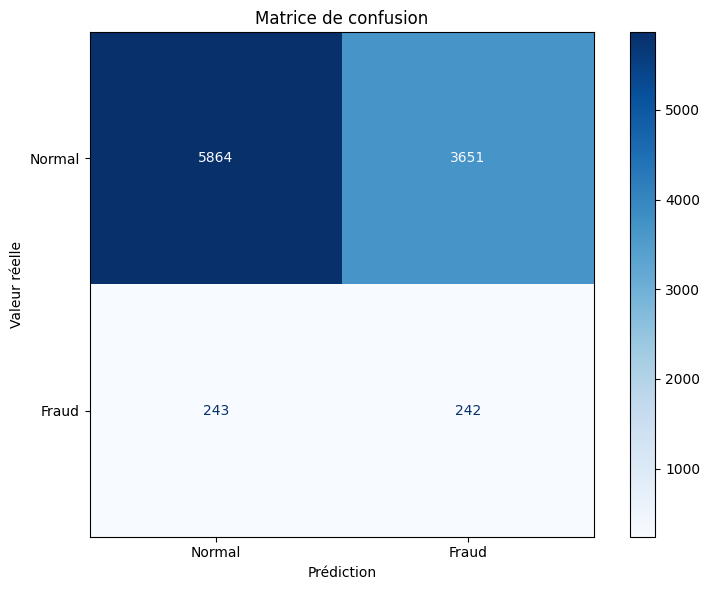

ROC-AUC et métriques
ROC AUC   : 0.5959
F1-score  : 0.1106
Recall    : 0.4990
Precision : 0.0622


<Figure size 640x480 with 0 Axes>

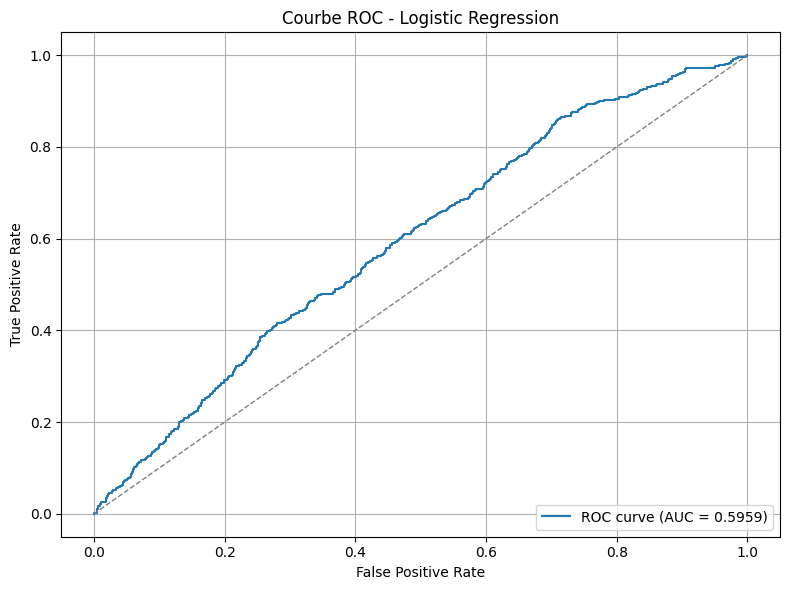

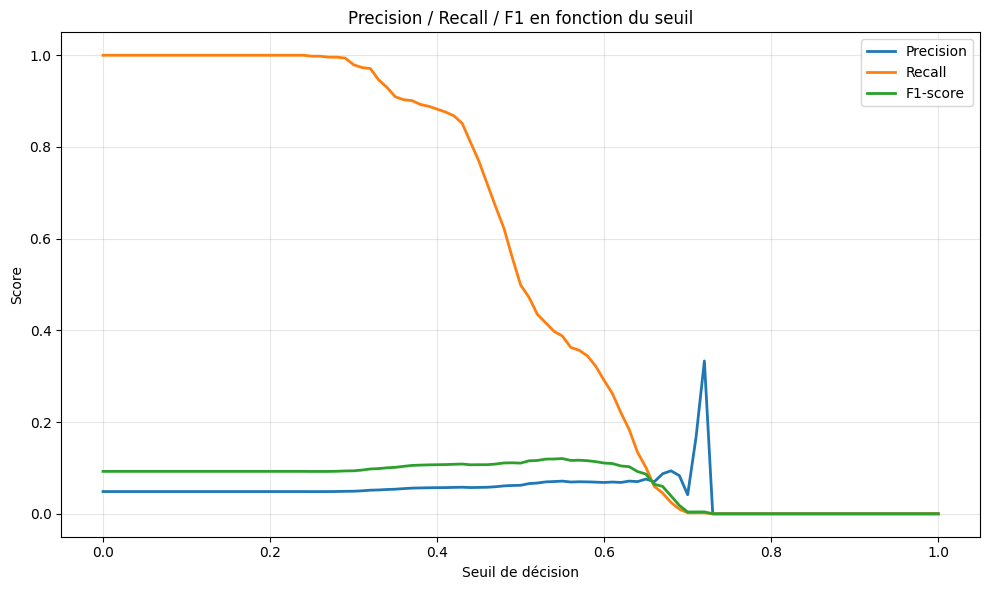

In [77]:
print("=" * 60)
print("PRESENTATION DES RESULTATS")
print("=" * 60)

## Matrice de confusion
# La matrice de confusion illustre les bonnes et mauvaises classifications.
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Fraud"]
)

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=plt.gca(), colorbar=True)
plt.title("Matrice de confusion")
plt.xlabel("Prédiction")
plt.ylabel("Valeur réelle")
plt.tight_layout()
plt.show()
plt.tight_layout()


## Courbe ROC-AUC
# On calcule les probabilités prédites pour la classe positive.
y_proba = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)

# Affichage du score ROC-AUC et des métriques principales.
print("=" * 50)
print("ROC-AUC et métriques")
print("=" * 50)
print(f"ROC AUC   : {roc_auc:.4f}")
print(f"F1-score  : {f1_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred, pos_label=1):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, pos_label=1):.4f}")

# Tracer la courbe ROC qui montre le compromis VRAI POSITIF / FAUX POSITIF.
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# Precision/Recall/F1 en fonction du seuil de classification.
thresholds = np.linspace(0.0, 1.0, 101)
precision_vals = []
recall_vals = []
f1_vals = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    precision_vals.append(precision_score(y_test, y_pred_thr, zero_division=0))
    recall_vals.append(recall_score(y_test, y_pred_thr, zero_division=0))
    f1_vals.append(f1_score(y_test, y_pred_thr, zero_division=0))

plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision_vals, label="Precision", linewidth=2)
plt.plot(thresholds, recall_vals, label="Recall", linewidth=2)
plt.plot(thresholds, f1_vals, label="F1-score", linewidth=2)
plt.xlabel("Seuil de décision")
plt.ylabel("Score")
plt.title("Precision / Recall / F1 en fonction du seuil")
plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()